**1. Data Cleaning & Preprocessing**

In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

In [8]:
df = pd.read_csv("D:\\loan_data.csv")

In [9]:
df.head()

df.info()

df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 255347 entries, 0 to 255346
Data columns (total 18 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   LoanID          255347 non-null  object 
 1   Age             255347 non-null  int64  
 2   Income          255347 non-null  int64  
 3   LoanAmount      255347 non-null  int64  
 4   CreditScore     255347 non-null  int64  
 5   MonthsEmployed  255347 non-null  int64  
 6   NumCreditLines  255347 non-null  int64  
 7   InterestRate    255347 non-null  float64
 8   LoanTerm        255347 non-null  int64  
 9   DTIRatio        255347 non-null  float64
 10  Education       255347 non-null  object 
 11  EmploymentType  255347 non-null  object 
 12  MaritalStatus   255347 non-null  object 
 13  HasMortgage     255347 non-null  object 
 14  HasDependents   255347 non-null  object 
 15  LoanPurpose     255347 non-null  object 
 16  HasCoSigner     255347 non-null  object 
 17  Default   

,Age,Income,LoanAmount,CreditScore,MonthsEmployed,NumCreditLines,InterestRate,LoanTerm,DTIRatio,Default
count,255347.000000,255347.000000,255347.000000,255347.000000,255347.000000,255347.000000,255347.000000,255347.000000,255347.000000,255347.000000
mean,43.498306,82499.304597,127578.865512,574.264346,59.541976,2.501036,13.492773,36.025894,0.500212,0.116128
std,14.990258,38963.013729,70840.706142,158.903867,34.643376,1.117018,6.636443,16.969330,0.230917,0.320379
min,18.000000,15000.000000,5000.000000,300.000000,0.000000,1.000000,2.000000,12.000000,0.100000,0.000000
25%,31.000000,48825.500000,66156.000000,437.000000,30.000000,2.000000,7.770000,24.000000,0.300000,0.000000
50%,43.000000,82466.000000,127556.000000,574.000000,60.000000,2.000000,13.460000,36.000000,0.500000,0.000000
75%,56.000000,116219.000000,188985.000000,712.000000,90.000000,3.000000,19.250000,48.000000,0.700000,0.000000
max,69.000000,149999.000000,249999.000000,849.000000,119.000000,4.000000,25.000000,60.000000,0.900000,1.000000


In [10]:
print(df.shape)

(255347, 18)


In [11]:
df.duplicated().sum()

np.int64(0)

In [12]:
df.drop_duplicates(inplace=True)

In [13]:
df.dtypes

LoanID             object
Age                 int64
Income              int64
LoanAmount          int64
CreditScore         int64
MonthsEmployed      int64
NumCreditLines      int64
InterestRate      float64
LoanTerm            int64
DTIRatio          float64
Education          object
EmploymentType     object
MaritalStatus      object
HasMortgage        object
HasDependents      object
LoanPurpose        object
HasCoSigner        object
Default             int64
dtype: object

*-Create New Features*

In [15]:
df['Loan_to_Income'] = df['LoanAmount'] / df['Income']  #Loan-to-Income Ratio

In [16]:
#Credit Score Category
df['Credit_Category'] = pd.cut(
    df['CreditScore'],
    bins=[300,550,650,750,850],
    labels=['Poor','Average','Good','Excellent']
)

In [17]:
#Income Category
df['Income_Group'] = pd.cut(
    df['Income'],
    bins=[0,30000,70000,200000],
    labels=['Low','Medium','High']
)

*-Export Clean Dataset*

In [20]:
df.to_csv("loan_cleaned.csv",index=False)

**2.Exploratory Data Analysis (EDA)**

*-Target Variable Analysis*

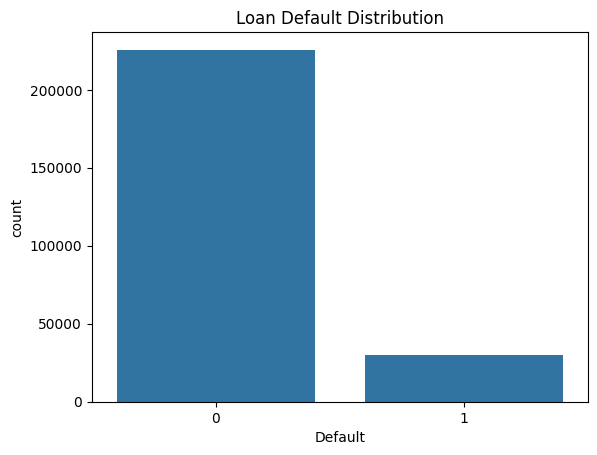

In [22]:
#Default Distribution
sns.countplot(x='Default',data=df)

plt.title("Loan Default Distribution")
plt.show()

#Insight:
Majority = Non-Default,
Minority = Default

*-Age Analysis*

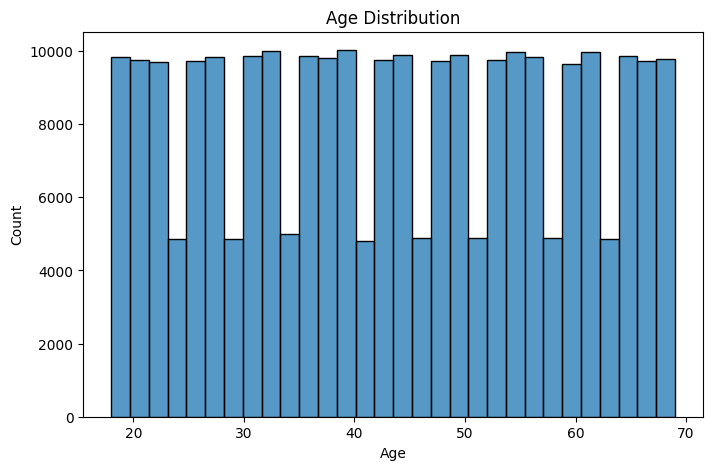

In [23]:
plt.figure(figsize=(8,5))

sns.histplot(df['Age'],bins=30)

plt.title("Age Distribution")
plt.show()

#Business Insight:
Identify dominant borrower age groups.

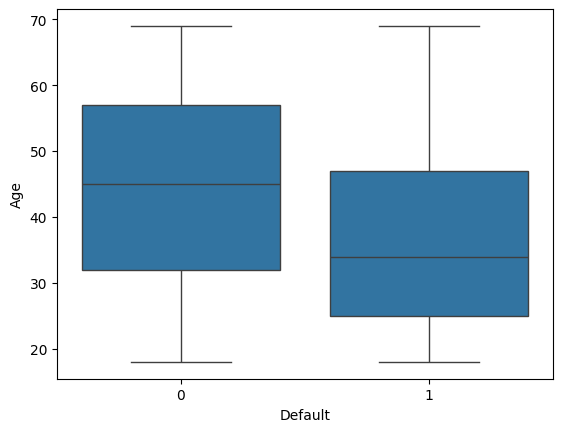

In [25]:
#Age Vs Default
sns.boxplot(
    x='Default',
    y='Age',
    data=df
)
plt.show()

*-Credit Score Analysis*

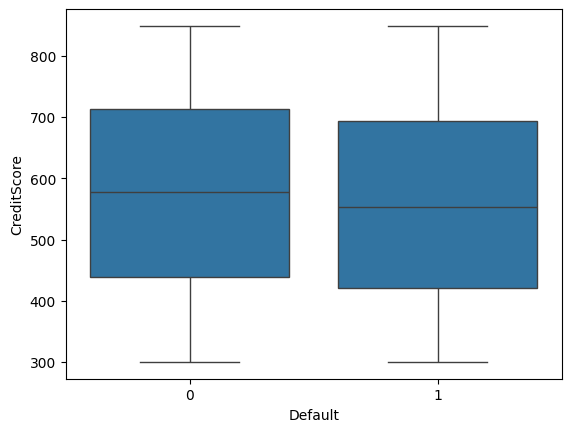

In [26]:
sns.boxplot(
    x='Default',
    y='CreditScore',
    data=df
)
plt.show()

In [27]:
#Credit Category Analysis
pd.crosstab(
    df['Credit_Category'],
    df['Default'],
    normalize='index'
)*100

Default,0,1
Credit_Category,,
Poor,87.429702,12.570298
Average,88.497784,11.502216
Good,89.189248,10.810752
Excellent,89.931256,10.068744


*-Loan Amount Analysis*

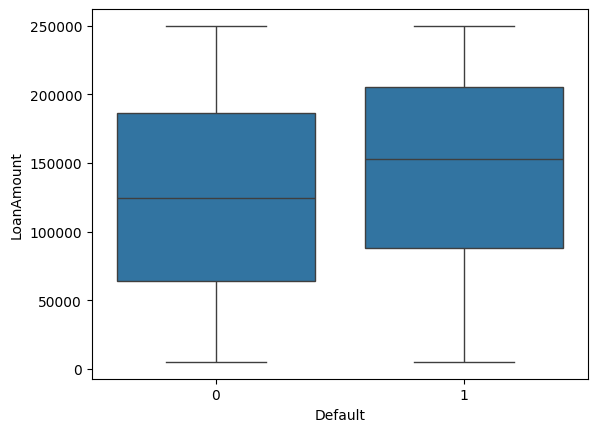

In [28]:
sns.boxplot(
    x='Default',
    y='LoanAmount',
    data=df
)
plt.show()

*-Interest Rate Analysis*

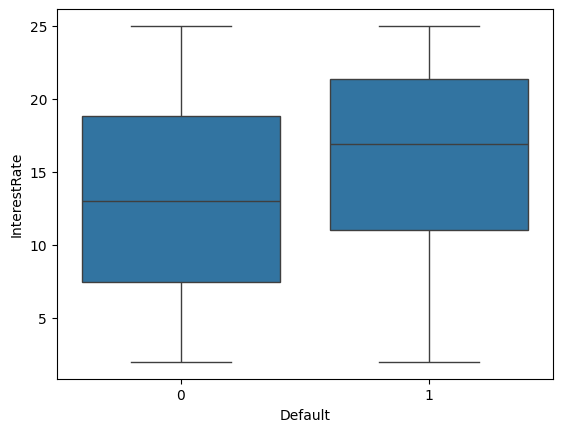

In [29]:
sns.boxplot(
    x='Default',
    y='InterestRate',
    data=df
)
plt.show()

*-Debt-to-Income Ratio (DTI)*

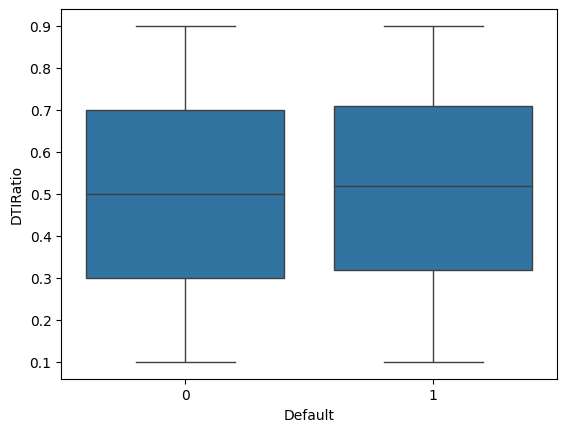

In [30]:
sns.boxplot(
    x='Default',
    y='DTIRatio',
    data=df
)
plt.show()

*-Loan Purpose Analysis*

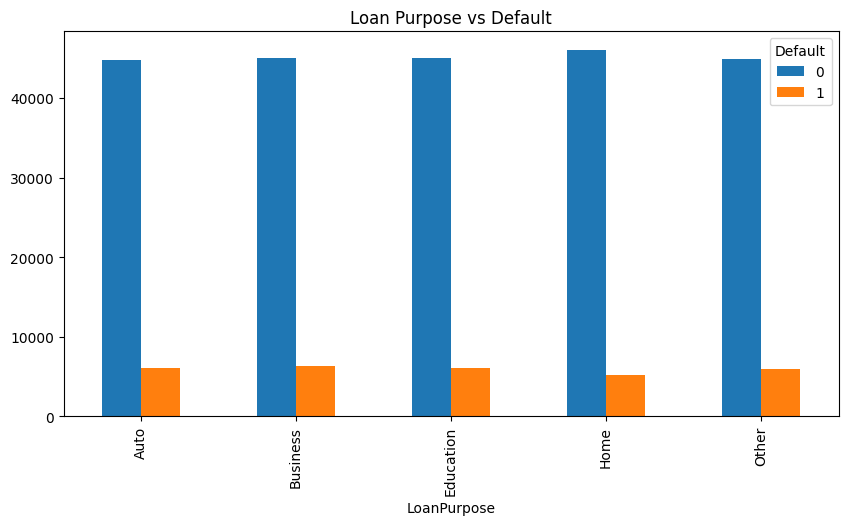

In [31]:
purpose_default = pd.crosstab(
    df['LoanPurpose'],
    df['Default']
)

purpose_default.plot(
    kind='bar',
    figsize=(10,5)
)

plt.title("Loan Purpose vs Default")
plt.show()

*-Employment Type Analysis*

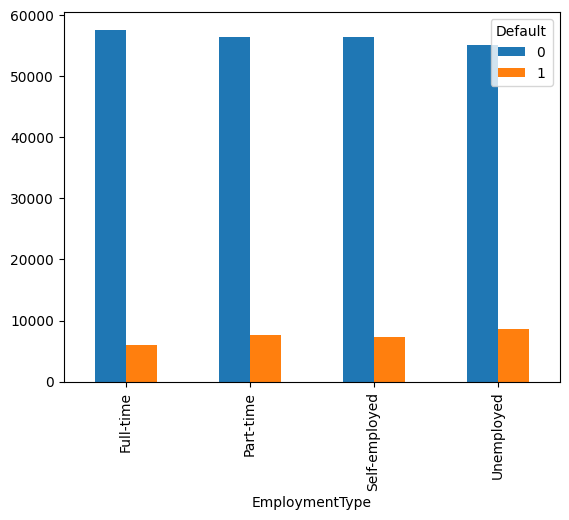

In [32]:
employment_default = pd.crosstab(
    df['EmploymentType'],
    df['Default']
)

employment_default.plot(
    kind='bar'
)

plt.show()

*-Correlation Heatmap*

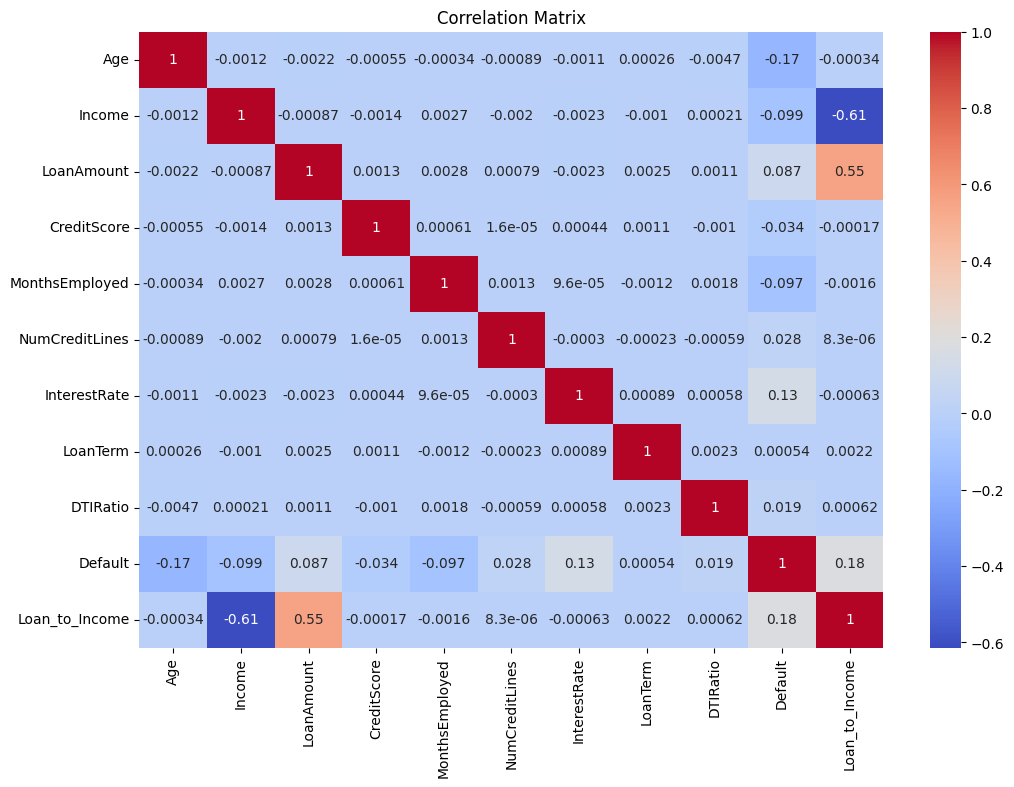

In [33]:
plt.figure(figsize=(12,8))

sns.heatmap(
    df.select_dtypes(include=np.number).corr(),
    annot=True,
    cmap='coolwarm'
)

plt.title("Correlation Matrix")

plt.show()